- Global Ridge (linear SARX) vs LightGBM (gradient-boosted trees) on identical pooled 146-station data
- Isolates the nonlinearity benefit; all evaluation in log space, horizons t+1 to t+14
- `station_id` as categorical feature; early stopping on validation set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import os

os.makedirs('../figures-log', exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

In [2]:
train_data = pd.read_feather('../checkpoints/train_data.feather')
val_data   = pd.read_feather('../checkpoints/val_data.feather')
test_data  = pd.read_feather('../checkpoints/test_data.feather')

benchmark = pd.read_csv('../data/benchmark.csv')
benchmark_ids = set(benchmark['Station'].astype(int).tolist())

train_data = train_data[train_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)
val_data   = val_data[val_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)
test_data  = test_data[test_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)

print('After benchmark filter:')
print(f'  train: {train_data.shape}  ({train_data["station_id"].nunique()} stations)')
print(f'  val  : {val_data.shape}  ({val_data["station_id"].nunique()} stations)')
print(f'  test : {test_data.shape}  ({test_data["station_id"].nunique()} stations)')

After benchmark filter:
  train: (1279836, 42)  (146 stations)
  val  : (106580, 42)  (146 stations)
  test : (251712, 42)  (146 stations)


In [3]:
HORIZONS = [1, 3, 7, 10, 14]
LAGS     = [1, 3, 7, 10, 14]

feature_cols = (
    ['flow', 'rainfall'] +
    [f'discharge_lag{i}' for i in LAGS] +
    [f'precip_lag{i}'    for i in LAGS] +
    ['month_sin', 'month_cos', 'bfi', 'area', 'saar']
)
print(f'Features ({len(feature_cols)}): {feature_cols}')


def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def kge(y_true, y_pred):
    if len(y_true) < 3 or np.std(y_true) == 0 or np.mean(y_true) == 0:
        return np.nan
    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta  = np.mean(y_pred) / np.mean(y_true)
    return np.nan if np.isnan(r) else 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)


def bootstrap_median_ci(values, n_boot=10000, ci=0.95):
    vals = values.dropna().values
    rng  = np.random.RandomState(42)
    boot = [np.median(rng.choice(vals, len(vals), replace=True)) for _ in range(n_boot)]
    a = (1 - ci) / 2
    return np.percentile(boot, [a * 100, (1 - a) * 100])

Features (17): ['flow', 'rainfall', 'discharge_lag1', 'discharge_lag3', 'discharge_lag7', 'discharge_lag10', 'discharge_lag14', 'precip_lag1', 'precip_lag3', 'precip_lag7', 'precip_lag10', 'precip_lag14', 'month_sin', 'month_cos', 'bfi', 'area', 'saar']


- All 142 stations pooled into a single Ridge model with per-station z-scoring on log1p(flow)
- Dynamic coefficients shared across stations; station-level offsets absorbed by z-scoring

In [4]:
def train_global_ridge_all_horizons(train_data, val_data, test_data,
                                     feature_cols, horizons=HORIZONS, alpha=10.0):
    _scalers, _means, _stds = {}, {}, {}
    for sid, grp in train_data.groupby("station_id"):
        Xtr = grp[feature_cols]
        valid = Xtr.notna().all(axis=1)
        if valid.sum() < 100: continue
        log_flow_vals = np.log1p(grp.loc[valid, "flow"])
        sstd = float(log_flow_vals.std())
        if sstd < 1e-8: continue
        sc = StandardScaler()
        sc.fit(Xtr[valid])
        _scalers[sid] = sc
        _means[sid]   = float(log_flow_vals.mean())
        _stds[sid]    = sstd

    all_results = []
    for h in horizons:
        print(f'\n{"="*60}')
        print(f'Global Ridge t+{h}  (log1p target, per-station z-score, alpha={alpha})')
        print(f'{"="*60}')

        X_parts, y_parts = [], []
        for sid, sc in _scalers.items():
            tr = train_data[train_data["station_id"]==sid].copy()
            tr["target"] = np.log1p(tr["flow"].shift(-h))
            valid = tr[feature_cols].notna().all(axis=1) & tr["target"].notna()
            if valid.sum() < 100: continue
            X_parts.append(sc.transform(tr.loc[valid, feature_cols]))
            y_parts.append((tr.loc[valid, "target"].values - _means[sid]) / _stds[sid])

        X_pool = np.vstack(X_parts)
        y_pool = np.concatenate(y_parts)
        model  = Ridge(alpha=alpha)
        model.fit(X_pool, y_pool)
        print(f'  Pooled train rows: {len(X_pool):,}')

        def predict_station(df_split):
            results = []
            for sid, grp in df_split.groupby("station_id"):
                if sid not in _scalers: continue
                g = grp.copy()
                g["target"] = np.log1p(g["flow"].shift(-h))
                valid = g[feature_cols].notna().all(axis=1) & g["target"].notna()
                g = g[valid]
                if len(g) < 10: continue
                y_pred = model.predict(_scalers[sid].transform(g[feature_cols])) * _stds[sid] + _means[sid]
                results.append({"station_id": sid,
                                 "nse": nse(g["target"].values, y_pred),
                                 "kge": kge(g["target"].values, y_pred),
                                 "rmse": np.sqrt(np.mean((g["target"].values - y_pred)**2))})
            return pd.DataFrame(results)

        val_df  = predict_station(val_data)
        test_df = predict_station(test_data)
        val_nse_med = val_df["nse"].median()
        print(f'  Val median log-NSE: {val_nse_med:.4f}')

        rdf = test_df.rename(columns={"nse":"test_nse","kge":"test_kge","rmse":"test_rmse"})
        rdf["horizon"]  = f"t+{h}"
        rdf["val_nse"]  = val_nse_med
        rdf["n_test"]   = rdf["station_id"].map(
            test_data.groupby("station_id").size())
        all_results.append(rdf)
        print(f'  Test median log-NSE: {rdf["test_nse"].median():.4f}  '
              f'KGE: {rdf["test_kge"].median():.4f}  (n={len(rdf)} stations)')

    return pd.concat(all_results, ignore_index=True)

In [5]:
global_ridge_results = train_global_ridge_all_horizons(
    train_data, val_data, test_data, feature_cols
)
global_ridge_results.to_csv('results/global_ridge_multihorizon_results.csv', index=False)

print('\nGlobal Ridge — Test Set Summary')
print('=' * 70)
t1_med = global_ridge_results.loc[global_ridge_results['horizon']=='t+1', 'test_nse'].median()
for h in HORIZONS:
    nse_v = global_ridge_results.loc[global_ridge_results['horizon']==f't+{h}', 'test_nse'].dropna()
    kge_v = global_ridge_results.loc[global_ridge_results['horizon']==f't+{h}', 'test_kge'].dropna()
    ci_n  = bootstrap_median_ci(nse_v)
    print(f'  t+{h:>2}: NSE={nse_v.median():.4f} [{ci_n[0]:.4f},{ci_n[1]:.4f}]  '
          f'KGE={kge_v.median():.4f}  (n={len(nse_v)})')


Global Ridge t+1  (log1p target, per-station z-score, alpha=10.0)


  Pooled train rows: 1,262,598


  Val median log-NSE: 0.7456
  Test median log-NSE: 0.7490  KGE: 0.7781  (n=142 stations)

Global Ridge t+3  (log1p target, per-station z-score, alpha=10.0)


  Pooled train rows: 1,262,194


  Val median log-NSE: 0.4888
  Test median log-NSE: 0.5082  KGE: 0.5807  (n=142 stations)

Global Ridge t+7  (log1p target, per-station z-score, alpha=10.0)


...

  Val median log-NSE: 0.2977
  Test median log-NSE: 0.3267  KGE: 0.4046  (n=142 stations)

Global Ridge t+14  (log1p target, per-station z-score, alpha=10.0)


  Pooled train rows: 1,260,150


  Val median log-NSE: 0.2879
  Test median log-NSE: 0.3122  KGE: 0.3700  (n=142 stations)

Global Ridge — Test Set Summary
  t+ 1: NSE=0.7490 [0.7193,0.7739]  KGE=0.7781  (n=142)


  t+ 3: NSE=0.5082 [0.4643,0.5539]  KGE=0.5807  (n=142)
  t+ 7: NSE=0.3814 [0.3549,0.4089]  KGE=0.4505  (n=142)


  t+10: NSE=0.3267 [0.3096,0.3721]  KGE=0.4046  (n=142)
  t+14: NSE=0.3122 [0.2893,0.3472]  KGE=0.3700  (n=142)


- LightGBM trained on same pooled log-transformed targets for direct NSE comparability with Ridge
- `station_id` as native categorical; early stopping (50 rounds) on validation set

In [6]:
def build_global_dataset(df, horizon, feature_cols):
    """Pool all stations; target = log1p(flow.shift(-h)) per station."""
    out = []
    for sid, grp in df.groupby('station_id'):
        g = grp.copy()
        g['target_raw'] = g['flow'].shift(-horizon)
        g = g.dropna(subset=['target_raw'] + feature_cols)
        g = g[g['target_raw'] > 0]
        g['target'] = np.log1p(g['target_raw'])
        out.append(g)
    return pd.concat(out, ignore_index=True)


LGBM_PARAMS = {
    'objective':         'regression',
    'metric':            'rmse',
    'learning_rate':     0.05,
    'n_estimators':      1000,
    'num_leaves':        63,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_lambda':        5.0,
    'reg_alpha':         0.1,
    'n_jobs':            -1,
    'random_state':      42,
    'verbose':           -1,
}
EARLY_STOPPING = 50

In [7]:
def train_lgbm_all_horizons(train_data, val_data, test_data,
                              feature_cols, horizons=HORIZONS):
    all_feat = feature_cols + ['station_id']
    all_results, models = [], {}

    for h in horizons:
        print(f'\n{"="*60}')
        print(f'LightGBM t+{h}  |  target = log1p(flow.shift(-{h}))  |  station_id = categorical')
        print(f'{"="*60}')

        tr = build_global_dataset(train_data, h, feature_cols)
        va = build_global_dataset(val_data,   h, feature_cols)
        te = build_global_dataset(test_data,  h, feature_cols)

        all_sids = sorted(set(tr['station_id'].unique()) |
                          set(va['station_id'].unique()) |
                          set(te['station_id'].unique()))
        cat_type = pd.CategoricalDtype(categories=all_sids)
        for df in [tr, va, te]:
            df['station_id'] = df['station_id'].astype(cat_type)

        X_tr, y_tr = tr[all_feat], tr['target']
        X_va, y_va = va[all_feat], va['target']
        print(f'  Train: {len(X_tr):,}  Val: {len(X_va):,}  Test: {len(te):,}')

        model = lgb.LGBMRegressor(**LGBM_PARAMS)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                  categorical_feature=['station_id'],
                  callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False),
                             lgb.log_evaluation(period=200)])
        best_iter = model.best_iteration_
        print(f'  Best iter: {best_iter}  val RMSE (log)={model.best_score_["valid_0"]["rmse"]:.4f}')

        va['pred'] = model.predict(X_va, num_iteration=best_iter)
        val_nse_med = np.median([nse(g['target'].values, g['pred'].values)
                                  for _, g in va.groupby('station_id') if len(g) >= 10])

        te['pred'] = model.predict(te[all_feat], num_iteration=best_iter)
        results = []
        for sid, grp in te.groupby('station_id'):
            y_t, y_p = grp['target'].values, grp['pred'].values
            if len(y_t) < 10: continue
            results.append({'station_id': sid, 'horizon': f't+{h}',
                             'val_nse': val_nse_med,
                             'test_nse': nse(y_t, y_p), 'test_kge': kge(y_t, y_p),
                             'test_rmse': np.sqrt(mean_squared_error(y_t, y_p)),
                             'n_test': len(y_t)})

        rdf = pd.DataFrame(results)
        all_results.append(rdf)
        models[f't+{h}'] = model
        print(f'  Test — log-NSE: {rdf["test_nse"].median():.4f}  KGE: {rdf["test_kge"].median():.4f}  '
              f'(n={len(rdf)} stations)')

    return pd.concat(all_results, ignore_index=True), models

In [8]:
lgbm_results, lgbm_models = train_lgbm_all_horizons(
    train_data, val_data, test_data, feature_cols
)
lgbm_results.to_csv('results/gbm_multihorizon_results.csv', index=False)

print('\nLightGBM — Test Set Summary')
print('=' * 70)
t1_med = lgbm_results.loc[lgbm_results['horizon']=='t+1', 'test_nse'].median()
for h in HORIZONS:
    nse_v = lgbm_results.loc[lgbm_results['horizon']==f't+{h}', 'test_nse'].dropna()
    kge_v = lgbm_results.loc[lgbm_results['horizon']==f't+{h}', 'test_kge'].dropna()
    ci_n  = bootstrap_median_ci(nse_v)
    ci_k  = bootstrap_median_ci(kge_v)
    print(f'  t+{h:>2}: NSE={nse_v.median():.4f} [{ci_n[0]:.4f},{ci_n[1]:.4f}]  '
          f'KGE={kge_v.median():.4f} [{ci_k[0]:.4f},{ci_k[1]:.4f}]  (n={len(nse_v)})')


LightGBM t+1  |  target = log1p(flow.shift(-1))  |  station_id = categorical


  Train: 1,258,202  Val: 102,884  Test: 204,768


[200]	valid_0's rmse: 0.22777


[400]	valid_0's rmse: 0.225869


[600]	valid_0's rmse: 0.22533


...

  t+ 1: NSE=0.8936 [0.8637,0.9127]  KGE=0.9061 [0.8919,0.9262]  (n=142)


  t+ 3: NSE=0.6186 [0.5766,0.6726]  KGE=0.6765 [0.6624,0.7250]  (n=142)


  t+ 7: NSE=0.4588 [0.4339,0.5021]  KGE=0.5293 [0.5033,0.5649]  (n=142)


  t+10: NSE=0.3988 [0.3758,0.4385]  KGE=0.4594 [0.4399,0.4909]  (n=142)


  t+14: NSE=0.3740 [0.3504,0.4057]  KGE=0.4178 [0.4008,0.4457]  (n=142)


In [9]:
naive = pd.read_csv('results/naive_multihorizon_results.csv')

rows = []
for h in HORIZONS:
    tag = f't+{h}'
    pers = naive[(naive['horizon']==tag)&(naive['model']=='persistence')]['test_nse'].median()
    clim = naive[(naive['horizon']==tag)&(naive['model']=='climatology')]['test_nse'].median()
    rglo = global_ridge_results[global_ridge_results['horizon']==tag]['test_nse'].median()
    gbm  = lgbm_results[lgbm_results['horizon']==tag]['test_nse'].median()
    rows.append({'Horizon': tag, 'Persistence': pers, 'Climatology': clim,
                 'Ridge (global)': rglo, 'LightGBM': gbm})

comp = pd.DataFrame(rows).set_index('Horizon')
print('Median Test NSE — All Models')
print(comp.round(4).to_string())
print()
print('Nonlinearity effect  (LightGBM - global Ridge):')
print((comp['LightGBM'] - comp['Ridge (global)']).round(4).to_string())
print()
print('LightGBM vs climatology:')
print((comp['LightGBM'] - comp['Climatology']).round(4).to_string())
print()
print('Global Ridge vs climatology:')
print((comp['Ridge (global)'] - comp['Climatology']).round(4).to_string())

Median Test NSE — All Models
         Persistence  Climatology  Ridge (global)  LightGBM
Horizon                                                    
t+1           0.7684       0.3397          0.7490    0.8936
t+3           0.4341       0.3402          0.5082    0.6186
t+7           0.1720       0.3404          0.3814    0.4588
t+10          0.0124       0.3403          0.3267    0.3988
t+14         -0.0864       0.3387          0.3122    0.3740

Nonlinearity effect  (LightGBM - global Ridge):
Horizon
t+1     0.1446
t+3     0.1105
t+7     0.0774
t+10    0.0722
t+14    0.0618

LightGBM vs climatology:
Horizon
t+1     0.5539
t+3     0.2784
t+7     0.1184
t+10    0.0585
t+14    0.0352

Global Ridge vs climatology:
Horizon
t+1     0.4093
t+3     0.1679
t+7     0.0410
t+10   -0.0136
t+14   -0.0265


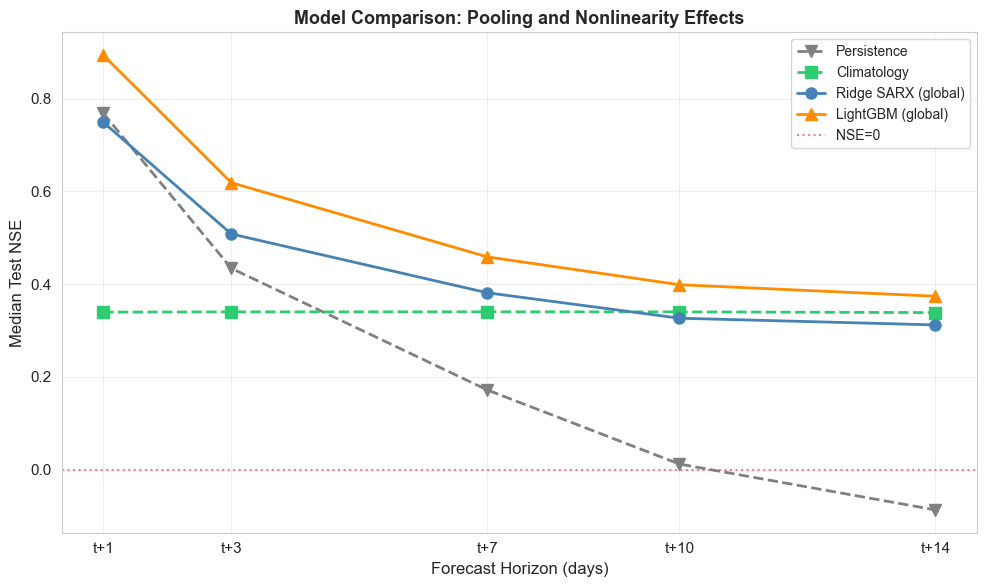

In [10]:
model_specs = [
    ('Persistence',         naive[naive['model']=='persistence'], 'grey',       'v', '--'),
    ('Climatology',         naive[naive['model']=='climatology'], '#2ecc71',    's', '--'),
    ('Ridge SARX (global)', global_ridge_results,                'steelblue',  'o', '-'),
    ('LightGBM (global)',   lgbm_results,                        'darkorange', '^', '-'),
]

fig, ax = plt.subplots(figsize=(10, 6))
for label, df, color, marker, ls in model_specs:
    meds = [df[df['horizon']==f't+{h}']['test_nse'].dropna().median() for h in HORIZONS]
    ax.plot(HORIZONS, meds, f'{marker}{ls}', color=color, linewidth=2,
            markersize=8, label=label, zorder=3)

ax.axhline(0, color='red', linestyle=':', alpha=0.5, label='NSE=0')
ax.set_xlabel('Forecast Horizon (days)', fontsize=12)
ax.set_ylabel('Median Test NSE', fontsize=12)
ax.set_title('Model Comparison: Pooling and Nonlinearity Effects',
             fontweight='bold', fontsize=13)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f't+{h}' for h in HORIZONS])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures-log/gbm_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

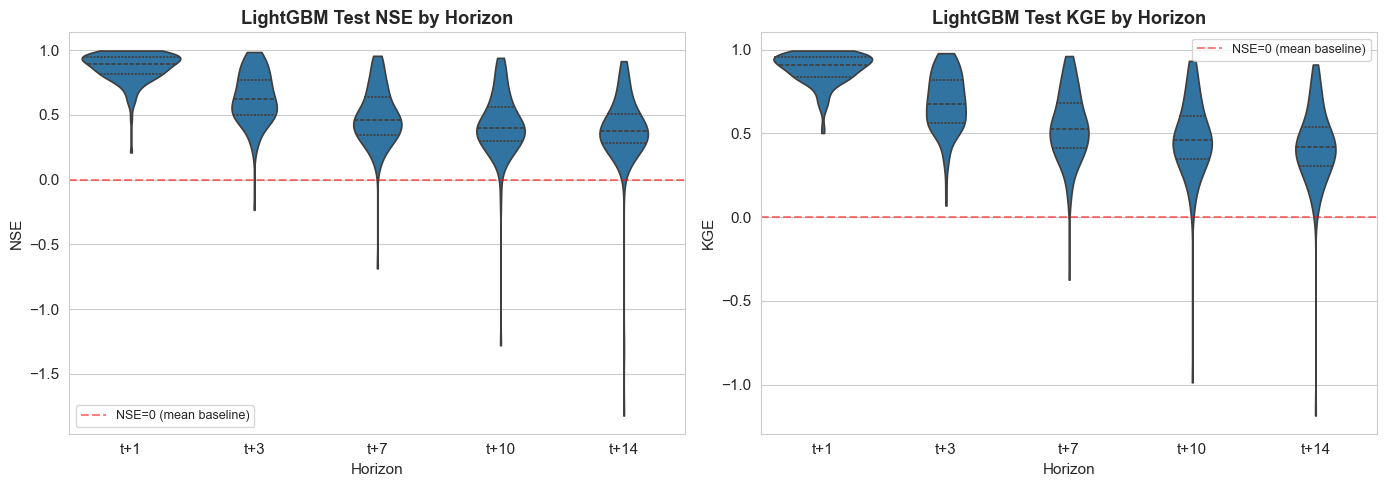

Threshold Analysis — LightGBM
Threshold            t+ 1  t+ 3  t+ 7  t+10  t+14
NSE < 0                0.0%    0.7%    0.7%    2.1%    2.1%
NSE < 0.3              0.7%    4.2%   12.7%   25.4%   29.6%
NSE >= 0.5            98.6%   74.6%   42.3%   30.3%   26.8%
KGE < 0                0.0%    0.0%    0.7%    1.4%    1.4%
KGE >= 0.5           100.0%   88.0%   58.5%   40.8%   31.7%


In [11]:
order = [f't+{h}' for h in HORIZONS]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['test_nse', 'test_kge'],
                               ['LightGBM Test NSE by Horizon', 'LightGBM Test KGE by Horizon']):
    sns.violinplot(data=lgbm_results, x='horizon', y=metric,
                   order=order, ax=ax, inner='quartile', cut=0)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='NSE=0 (mean baseline)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Horizon')
    ax.set_ylabel(metric.split('_')[1].upper())
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures-log/gbm_nse_kge_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Threshold Analysis — LightGBM')
print(f'{"Threshold":<20}', '  '.join(f't+{h:>2}' for h in HORIZONS))
for lbl, col, fn in [
    ('NSE < 0',    'test_nse', lambda x: x < 0),
    ('NSE < 0.3',  'test_nse', lambda x: x < 0.3),
    ('NSE >= 0.5', 'test_nse', lambda x: x >= 0.5),
    ('KGE < 0',    'test_kge', lambda x: x < 0),
    ('KGE >= 0.5', 'test_kge', lambda x: x >= 0.5),
]:
    vals = [f"{fn(lgbm_results.loc[lgbm_results['horizon']==f't+{h}', col].dropna()).mean()*100:5.1f}%"
            for h in HORIZONS]
    print(f'{lbl:<20}', '  '.join(vals))

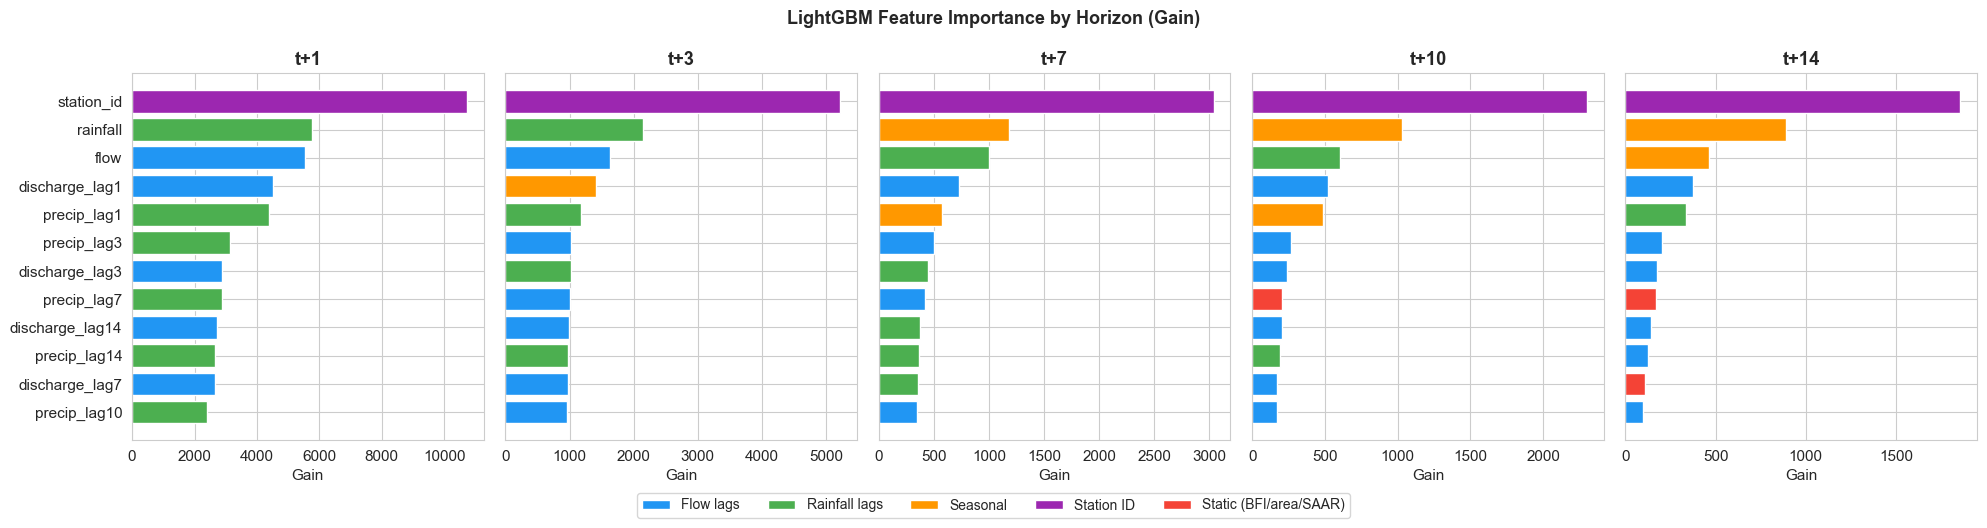

In [12]:
all_feat = feature_cols + ['station_id']
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(20, 5), sharey=False)
for ax, h in zip(axes, HORIZONS):
    imp = pd.Series(lgbm_models[f't+{h}'].feature_importances_, index=all_feat)
    imp = imp.sort_values(ascending=True).tail(12)
    colors = []
    for feat in imp.index:
        if 'discharge' in feat or feat == 'flow': colors.append('#2196F3')
        elif 'precip' in feat or feat == 'rainfall': colors.append('#4CAF50')
        elif 'month' in feat: colors.append('#FF9800')
        elif feat == 'station_id': colors.append('#9C27B0')
        else: colors.append('#F44336')
    ax.barh(imp.index, imp.values, color=colors)
    ax.set_title(f't+{h}', fontweight='bold')
    ax.set_xlabel('Gain')
    if ax != axes[0]: ax.set_yticklabels([])

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#2196F3', label='Flow lags'),
    Patch(facecolor='#4CAF50', label='Rainfall lags'),
    Patch(facecolor='#FF9800', label='Seasonal'),
    Patch(facecolor='#9C27B0', label='Station ID'),
    Patch(facecolor='#F44336', label='Static (BFI/area/SAAR)'),
], loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), fontsize=10)
plt.suptitle('LightGBM Feature Importance by Horizon (Gain)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures-log/gbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Lag-1 Residual ACF Comparison
Horizon       Ridge     LightGBM    Reduction
t+1          0.052        0.629      -0.577
t+3          0.530        0.647      -0.117
t+7          0.609        0.665      -0.056
t+10         0.633        0.676      -0.043
t+14         0.640        0.677      -0.037


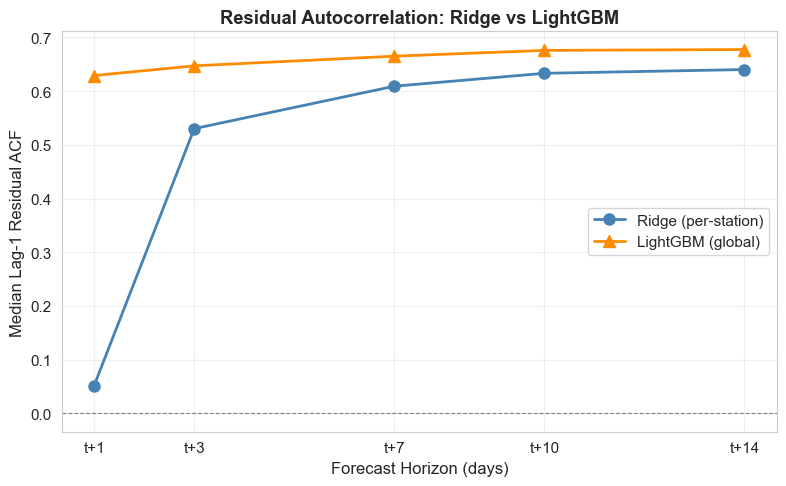

In [13]:
ridge_acf = {1: 0.052, 3: 0.530, 7: 0.609, 10: 0.633, 14: 0.640}  # global Ridge ACF

gbm_acf = {}
for h in HORIZONS:
    te = build_global_dataset(test_data, h, feature_cols)
    te['station_id'] = te['station_id'].astype('category')
    te['pred'] = np.maximum(lgbm_models[f't+{h}'].predict(te[feature_cols + ['station_id']]), 0)
    te['resid'] = te['target_raw'] - te['pred']
    acf_vals = []
    for sid, grp in te.groupby('station_id'):
        r = grp['resid'].dropna().values
        if len(r) > 10:
            acf_vals.append(np.corrcoef(r[:-1], r[1:])[0, 1])
    gbm_acf[h] = np.median(acf_vals)

print('Lag-1 Residual ACF Comparison')
print(f'{"Horizon":<8} {"Ridge":>10} {"LightGBM":>12} {"Reduction":>12}')
for h in HORIZONS:
    print(f't+{h:<5} {ridge_acf[h]:>10.3f} {gbm_acf[h]:>12.3f} {ridge_acf[h]-gbm_acf[h]:>+11.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(HORIZONS, [ridge_acf[h] for h in HORIZONS], 'o-', color='steelblue',
        linewidth=2, markersize=8, label='Ridge (per-station)')
ax.plot(HORIZONS, [gbm_acf[h] for h in HORIZONS], '^-', color='darkorange',
        linewidth=2, markersize=8, label='LightGBM (global)')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Forecast Horizon (days)', fontsize=12)
ax.set_ylabel('Median Lag-1 Residual ACF', fontsize=12)
ax.set_title('Residual Autocorrelation: Ridge vs LightGBM', fontweight='bold')
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f't+{h}' for h in HORIZONS])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../latex-report/figures/gbm_residual_acf.png', dpi=150, bbox_inches='tight')
plt.show()

Spearman r(BFI, NSE)  —  diagnostic: does GBM reduce BFI-skill dependency?
Horizon    Ridge (global)     LightGBM
t+1                0.674        0.611
t+3                0.734        0.689
t+7                0.753        0.714
t+10               0.747        0.690
t+14               0.743        0.683


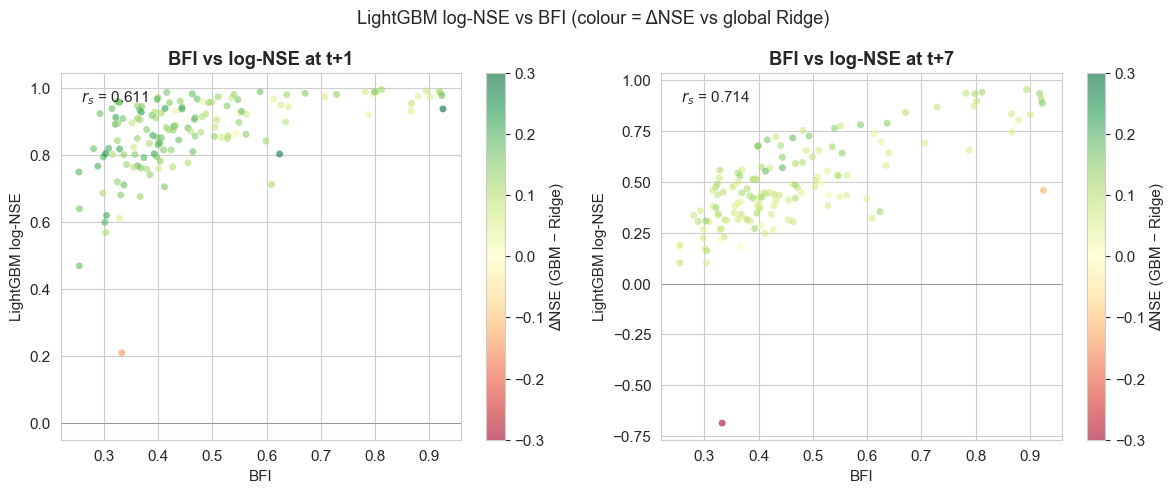

In [14]:
from scipy.stats import spearmanr

static = train_data.groupby('station_id')[['bfi', 'area', 'saar']].first().reset_index()

print('Spearman r(BFI, NSE)  —  diagnostic: does GBM reduce BFI-skill dependency?')
print(f'{"Horizon":<8} {"Ridge (global)":>16} {"LightGBM":>12}')
for h in HORIZONS:
    tag = f't+{h}'
    gr = global_ridge_results[global_ridge_results['horizon']==tag][['station_id','test_nse']]
    gr = gr.merge(static, on='station_id').dropna()
    rs_gr, _ = spearmanr(gr['bfi'], gr['test_nse'])
    gm = lgbm_results[lgbm_results['horizon']==tag][['station_id','test_nse']]
    gm = gm.merge(static, on='station_id').dropna()
    rs_gm, _ = spearmanr(gm['bfi'], gm['test_nse'])
    print(f't+{h:<5} {rs_gr:>16.3f} {rs_gm:>12.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tag in zip(axes, ['t+1', 't+7']):
    gm = lgbm_results[lgbm_results['horizon']==tag][['station_id','test_nse']]
    rp = global_ridge_results[global_ridge_results['horizon']==tag][['station_id','test_nse']].rename(
         columns={'test_nse': 'nse_ridge'})
    merged = gm.merge(rp, on='station_id').merge(static, on='station_id').dropna()
    merged['delta'] = merged['test_nse'] - merged['nse_ridge']
    sc = ax.scatter(merged['bfi'], merged['test_nse'], c=merged['delta'],
                    cmap='RdYlGn', vmin=-0.3, vmax=0.3, alpha=0.6, s=25, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='\u0394NSE (GBM \u2212 Ridge)')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_xlabel('BFI', fontsize=11)
    ax.set_ylabel('LightGBM log-NSE', fontsize=11)
    ax.set_title(f'BFI vs log-NSE at {tag}', fontweight='bold')
    rs, _ = spearmanr(merged['bfi'], merged['test_nse'])
    ax.annotate(f'$r_s$ = {rs:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11)
plt.suptitle('LightGBM log-NSE vs BFI (colour = \u0394NSE vs global Ridge)', fontsize=13)
plt.tight_layout()
plt.savefig('../figures-log/gbm_bfi_nse.png', dpi=150, bbox_inches='tight')
plt.show()

- LightGBM reduces lag-1 residual ACF vs Ridge, recovering temporally structured signal
- Weaker Spearman r_s(BFI, NSE) confirms preferential improvement at low-BFI (flashy) stations